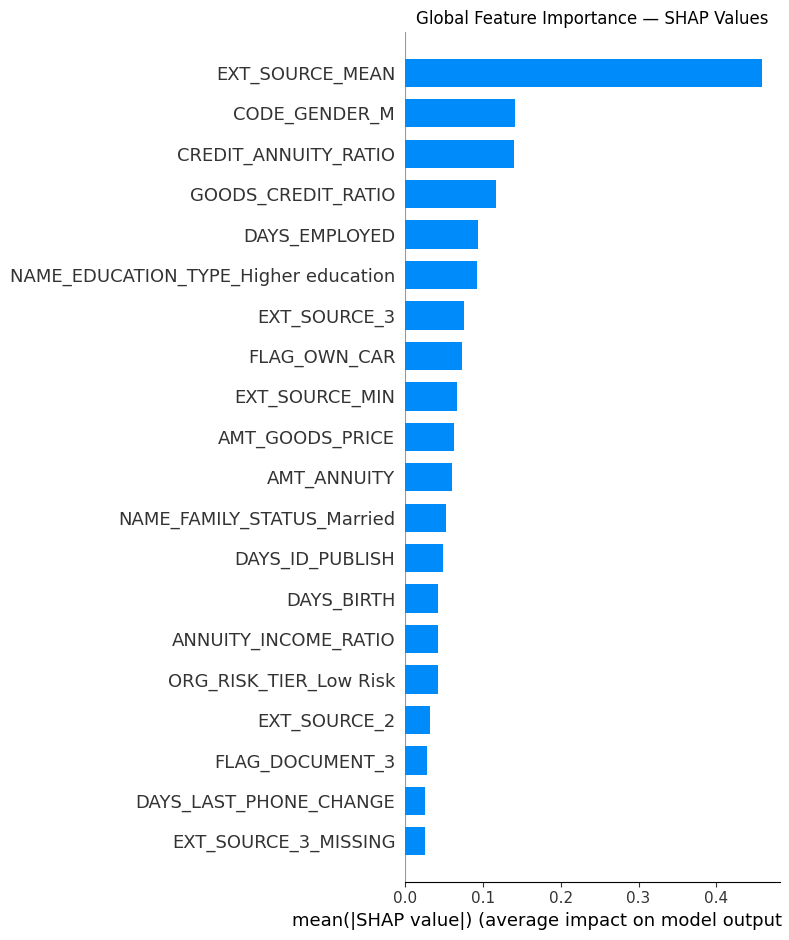

SHAP summary saved


In [1]:
import pandas as pd
import numpy as np
import shap
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split
from xgboost import XGBClassifier

df = pd.read_csv('../data/processed/application_train_features.csv')

X = df.drop(columns=['TARGET', 'SK_ID_CURR'])
y = df['TARGET']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

neg = (y_train == 0).sum()
pos = (y_train == 1).sum()

xgb_model = XGBClassifier(
    n_estimators=200,
    max_depth=4,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=neg/pos,
    eval_metric='auc',
    random_state=42,
    verbosity=0
)

xgb_model.fit(X_train, y_train)

explainer = shap.TreeExplainer(xgb_model)
shap_values = explainer.shap_values(X_test.iloc[:500])

shap.summary_plot(shap_values, X_test.iloc[:500],
                  plot_type='bar',
                  show=False)
plt.title('Global Feature Importance — SHAP Values')
plt.tight_layout()
plt.savefig('../reports/shap_summary.png', dpi=150)
plt.show()
print("SHAP summary saved")

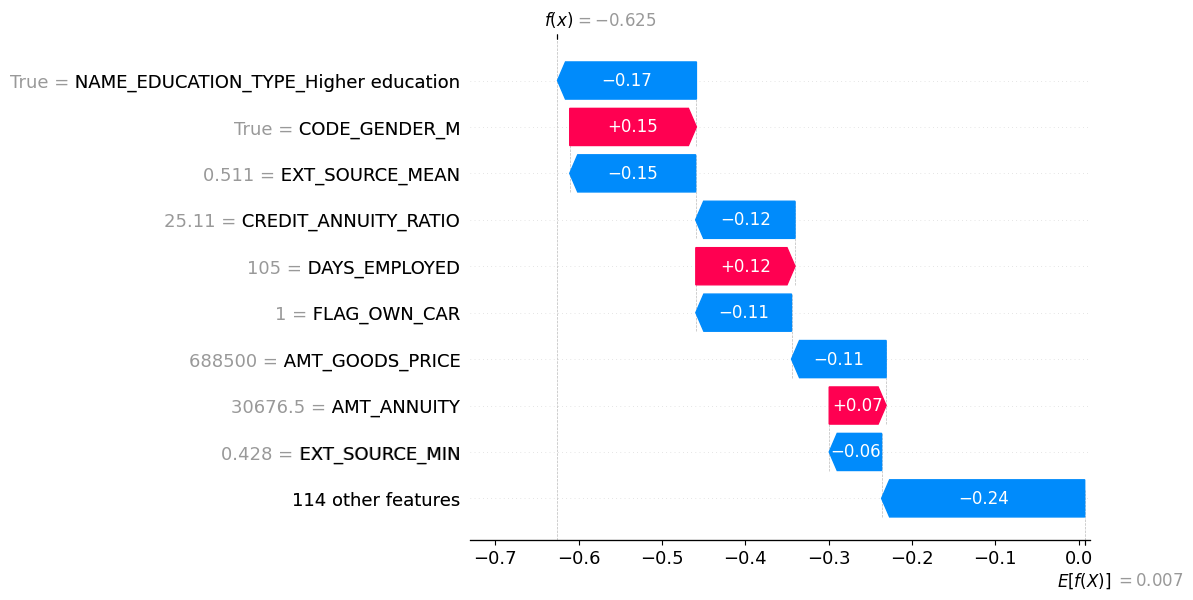

<Figure size 640x480 with 0 Axes>

Applicant default probability: 34.85 %


In [2]:
shap.waterfall_plot(shap.Explanation(
    values=shap_values[0],
    base_values=explainer.expected_value,
    data=X_test.iloc[0],
    feature_names=X_test.columns.tolist()
))
plt.savefig('../reports/shap_waterfall.png', dpi=150, bbox_inches='tight')
plt.show()
print("Applicant default probability:", round(xgb_model.predict_proba(X_test.iloc[[0]])[0][1] * 100, 2), "%")

In [3]:
print("Phase 4 complete - SHAP explainability done")
print("Reports saved: shap_summary.png, shap_waterfall.png")

Phase 4 complete - SHAP explainability done
Reports saved: shap_summary.png, shap_waterfall.png
